In [55]:
import math
import heapq
import numpy as np
from utils.run_experiment import *

In [56]:
ops_count = 0

def reset_ops():
    global ops_count
    ops_count = 0

# Classic

In [57]:
def dijkstra_classic_heap(adj_list, start_node):
    global ops_count
    reset_ops()
    
    n = len(adj_list)
    dist = [float('inf')] * n
    dist[start_node] = 0
    pq = [(0, start_node)]
    
    while pq:
        d, u = heapq.heappop(pq)
        ops_count += math.log2(max(len(pq) + 1, 2)) 
        
        if d > dist[u]: continue
            
        for v, w in adj_list[u]:
            new_dist = d + w
            if new_dist < dist[v]:
                dist[v] = new_dist
                heapq.heappush(pq, (new_dist, v))
                ops_count += math.log2(max(len(pq), 2))
                
    return dist, int(ops_count)

In [58]:
def bellman_ford_classic(n, edges, start=0):
    global ops_count
    reset_ops()
    
    dist = [float('inf')] * n
    dist[start] = 0
    
    for _ in range(n - 1):
        updated = False
        for u, v, w in edges:
            ops_count += 1 
            if dist[u] != float('inf') and dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                updated = True
        if not updated:
            break
            
    return dist, ops_count

In [59]:
def adj_to_matrix(adj_list):
    n = len(adj_list)
    INF = float('inf')
    mat = [[INF]*n for _ in range(n)]
    for i in range(n): 
        mat[i][i] = 0
    for u in range(n):
        for v, w in adj_list[u]:
            if w < mat[u][v]:
                mat[u][v] = w
    return mat


def floyd_warshall_classic(matrix):
    global ops_count
    reset_ops()
    n = len(matrix)
    dist = [row[:] for row in matrix]
    
    for k in range(n):
        for i in range(n):
            if dist[i][k] == float('inf'):
                continue
            for j in range(n):
                ops_count += 1 
                new_dist = dist[i][k] + dist[k][j]
                if new_dist < dist[i][j]:
                    dist[i][j] = new_dist
                    
    return dist, ops_count

# Quantum

In [60]:
def grover(target_state: str, initial_state: np.ndarray, num_iterations: int = 1):
    n = len(target_state)
    N = 2 ** n
    if len(initial_state) != N:
        if len(initial_state) < N:
            temp = np.zeros(N)
            temp[:len(initial_state)] = initial_state
            initial_state = temp
        else:
            initial_state = initial_state[:N]
            
    norm = np.linalg.norm(initial_state)
    if norm == 0: 
        return initial_state, np.zeros(N)
    if not np.isclose(norm, 1.0):
        initial_state = initial_state / norm

    target_index = int(target_state, 2)
    state = initial_state.copy()

    for _ in range(num_iterations):
        state[target_index] *= -1
        mean = np.mean(state)
        state = 2 * mean - state

    probabilities = np.abs(state) ** 2

    return state, probabilities

In [61]:
def quantum_min_search(distances: list, visited: list):
    global ops_count
    
    n_vertices = len(distances)
    candidates = [i for i in range(n_vertices) if not visited[i]]
    
    if not candidates: return -1
    if len(candidates) == 1: 
        ops_count += 1
        return candidates[0]

    # Находим реальный минимум для цели 
    min_val = float('inf')
    min_idx = -1
    for i in candidates:
        if distances[i] < min_val:
            min_val = distances[i]
            min_idx = i
            
    # Параметры для Гровера
    n_qubits = int(np.ceil(np.log2(n_vertices)))
    N = 2 ** n_qubits
    
    initial_state = np.ones(N) / np.sqrt(N)
    target_binary = format(min_idx, f'0{n_qubits}b')
    
    # Число итераций ~ pi/4 * sqrt(N)
    num_iters = max(1, int(np.round((np.pi / 4) * np.sqrt(N))))
    
    _, probs = grover(target_binary, initial_state, num_iters)
    measured_index = np.argmax(probs)
    
    # Эвристика затрат: одна операция поиска стоит sqrt(N)
    ops_count += int(np.sqrt(n_vertices))
    
    if measured_index >= n_vertices or visited[measured_index]:
        return min_idx
        
    return measured_index

In [62]:
def dijkstra_quantum(adj_list, start_node):
    global ops_count
    reset_ops()
    
    n = len(adj_list)
    dist = [float('inf')] * n
    visited = [False] * n
    dist[start_node] = 0
    
    for _ in range(n):
        u = quantum_min_search(dist, visited)
        if u == -1 or dist[u] == float('inf'): break
        visited[u] = True
        
        for v, w in adj_list[u]:
            if not visited[v] and dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                
    return dist, ops_count

In [72]:
def bellman_ford_quantum(n, edges, start=0):
    global ops_count
    reset_ops()
    
    dist = [float('inf')] * n
    dist[start] = 0
    E = len(edges)
    if E == 0: 
        return dist, 0

    n_qubits = int(np.ceil(np.log2(max(E, 1))))
    N = 2 ** n_qubits
    initial_state = np.ones(N) / np.sqrt(N)
    num_iters = max(1, int(np.round((np.pi / 4) * np.sqrt(N))))

    for _ in range(n - 1):
        best_gain = 0
        best_idx = -1
        
        for i, (u, v, w) in enumerate(edges):
            gain = dist[u] + w - dist[v]
            if gain > best_gain and dist[u] != float('inf'):
                best_gain = gain
                best_idx = i
                
        ops_count += int(np.sqrt(E))
        
        if best_idx == -1:
            break
            
        target_binary = format(best_idx, f'0{n_qubits}b')
        _, probs = grover(target_binary, initial_state, num_iters)
        measured_index = np.argmax(probs)
        
        actual_idx = measured_index if measured_index < E else best_idx
        u, v, w = edges[actual_idx]
        
        if dist[u] != float('inf') and dist[u] + w < dist[v]:
            dist[v] = dist[u] + w
            
    return dist, ops_count

In [64]:
def floyd_warshall_quantum(matrix):
    global ops_count
    reset_ops()
    n = len(matrix)
    dist = [row[:] for row in matrix]
    
    if n == 0: return dist, 0
    
    n_qubits = int(np.ceil(np.log2(max(n, 1))))
    N = 2 ** n_qubits
    initial_state = np.ones(N) / np.sqrt(N)
    num_iters = max(1, int(np.round((np.pi / 4) * np.sqrt(N))))

    for k in range(n):
        for i in range(n):
            if dist[i][k] == float('inf'): continue
            
            min_val = float('inf')
            best_j = -1
            
            for j in range(n):
                val = dist[i][k] + dist[k][j]
                if val < min_val:
                    min_val = val
                    best_j = j
            
            ops_count += int(np.sqrt(n))
            
            if best_j == -1 or min_val >= dist[i][best_j]:
                continue
                
            target_binary = format(best_j, f'0{n_qubits}b')
            _, probs = grover(target_binary, initial_state, num_iters)
            measured_j = np.argmax(probs)
            
            actual_j = measured_j if measured_j < n else best_j
            new_dist = dist[i][k] + dist[k][actual_j]
            
            if new_dist < dist[i][actual_j]:
                dist[i][actual_j] = new_dist
                
    return dist, ops_count

# Experiment

In [73]:
def dijkstra_classic_wrapper(adj_list, n, edges):
    return dijkstra_classic_heap(adj_list, 0)

def dijkstra_quantum_wrapper(adj_list, n, edges):
    return dijkstra_quantum(adj_list, 0)

def bellman_ford_classic_wrapper(adj_list, n, edges):
    return bellman_ford_classic(n, edges)

def bellman_ford_quantum_wrapper(adj_list, n, edges):
    return bellman_ford_quantum(n, edges)

def floyd_warshall_classic_wrapper(adj_list, n, edges):
    return floyd_warshall_classic(adj_to_matrix(adj_list))

def floyd_warshall_quantum_wrapper(adj_list, n, edges):
    return floyd_warshall_quantum(adj_to_matrix(adj_list))

algos = {
    "Dijkstra Classic (Heap)": dijkstra_classic_wrapper,
    "Dijkstra Quantum (Grover)": dijkstra_quantum_wrapper,
    "Bellman-Ford Classic": bellman_ford_classic_wrapper,
    "Bellman-Ford Quantum": bellman_ford_quantum_wrapper,
    #"Floyd-Warshall Classic": floyd_warshall_classic_wrapper,
    #"Floyd-Warshall Quantum": floyd_warshall_quantum_wrapper
}

res = run_experiment(algos)

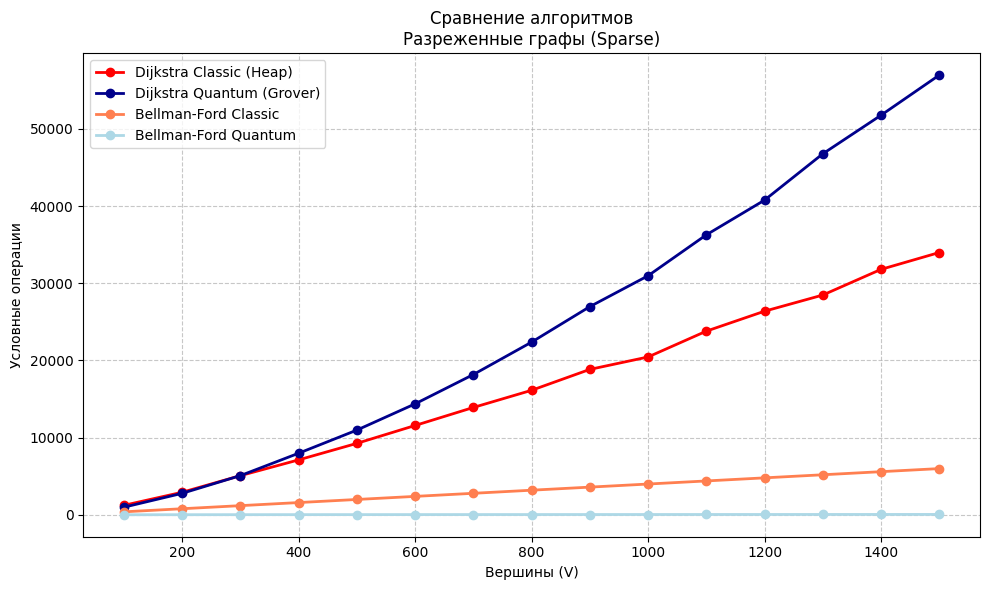

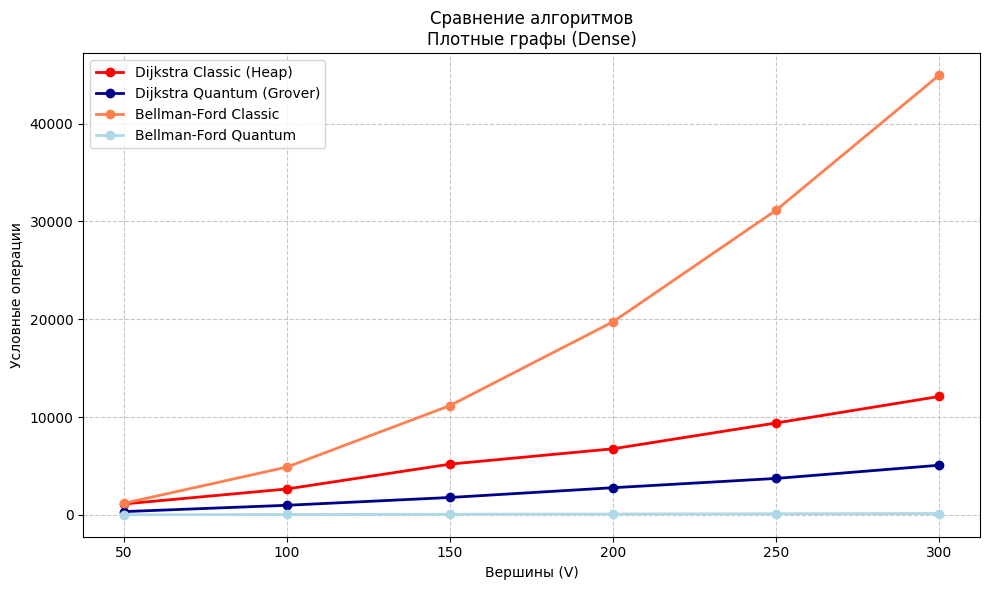

In [74]:
plot_results(res)

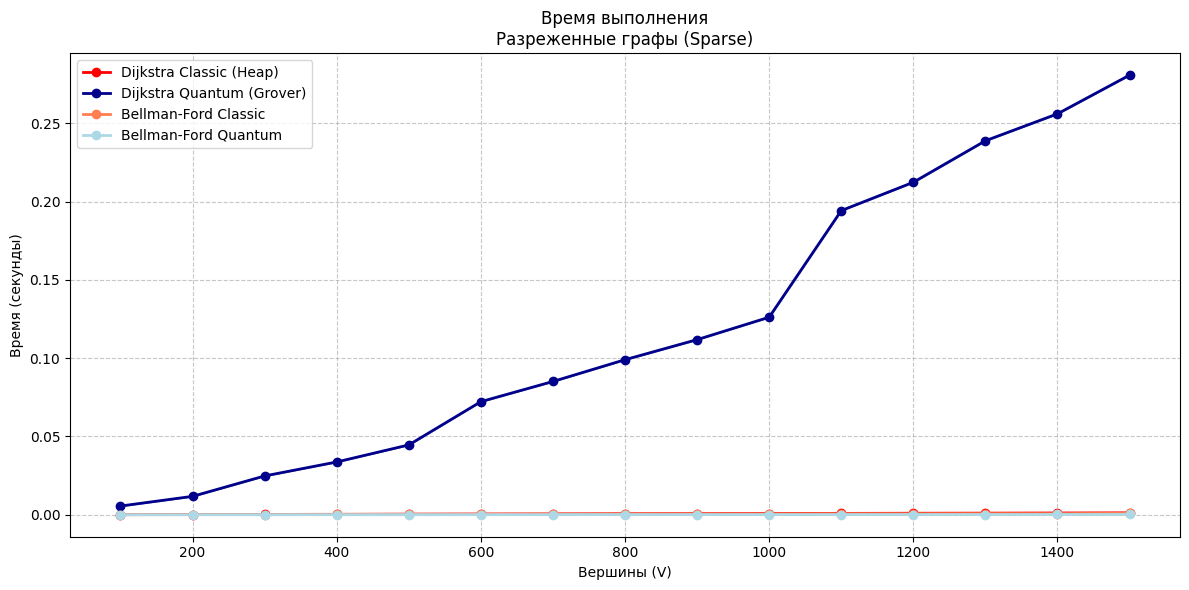

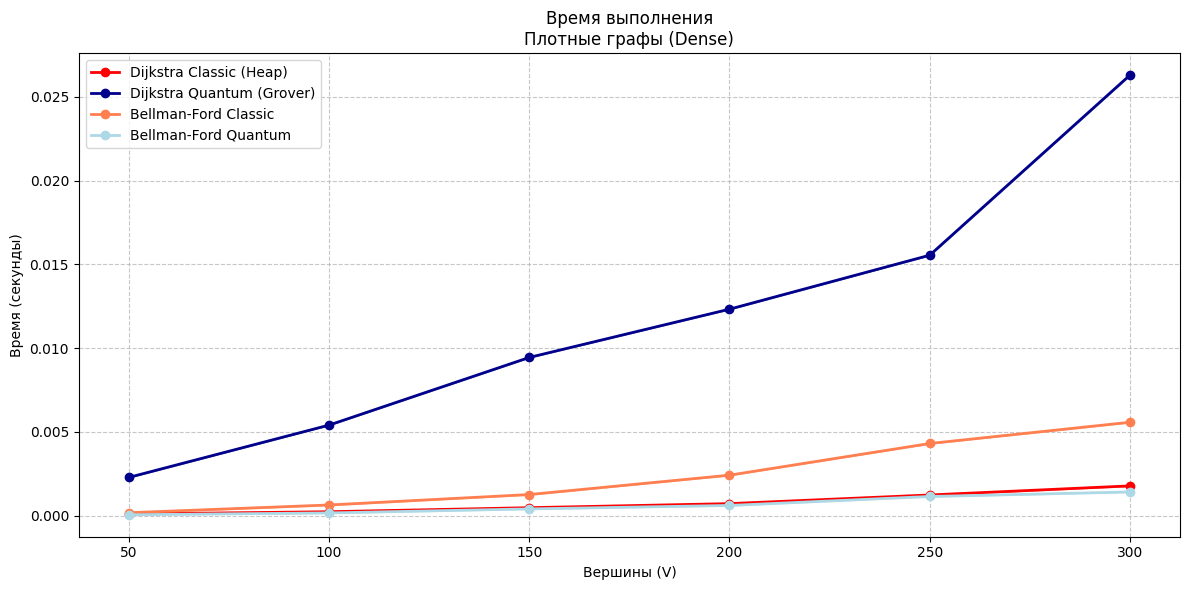

In [67]:
plot_time(res)

In [76]:
filtered_res = {k: v for k, v in res.items() if k != 'Dijkstra Quantum (Grover)'}

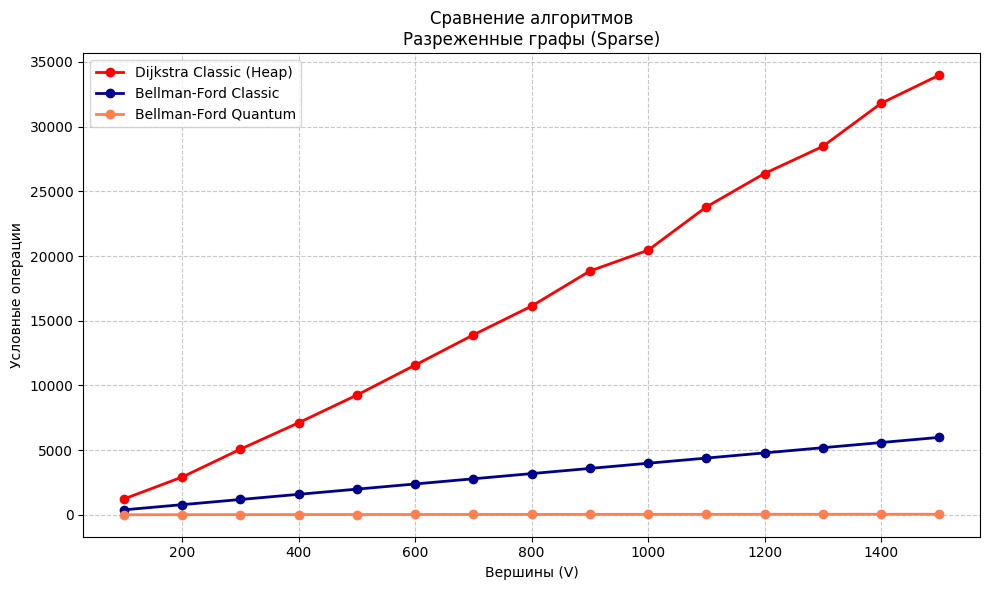

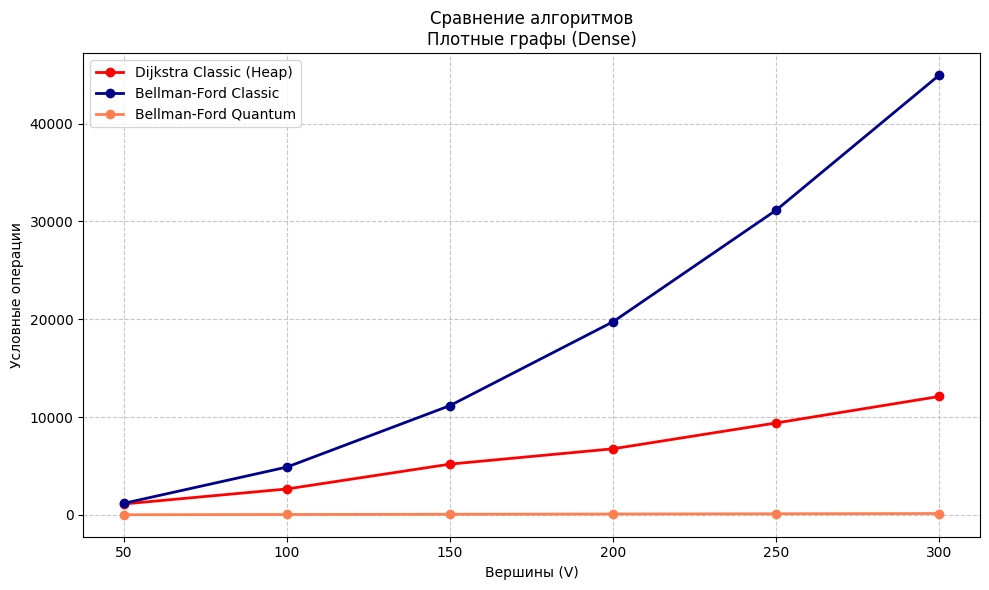

In [77]:
plot_results(filtered_res)

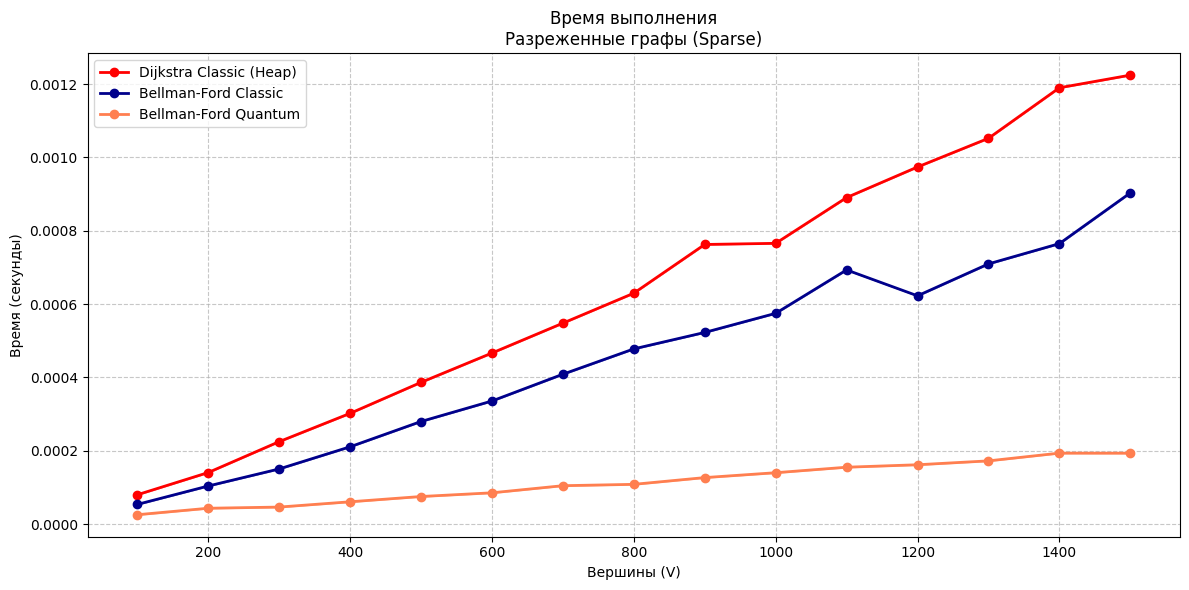

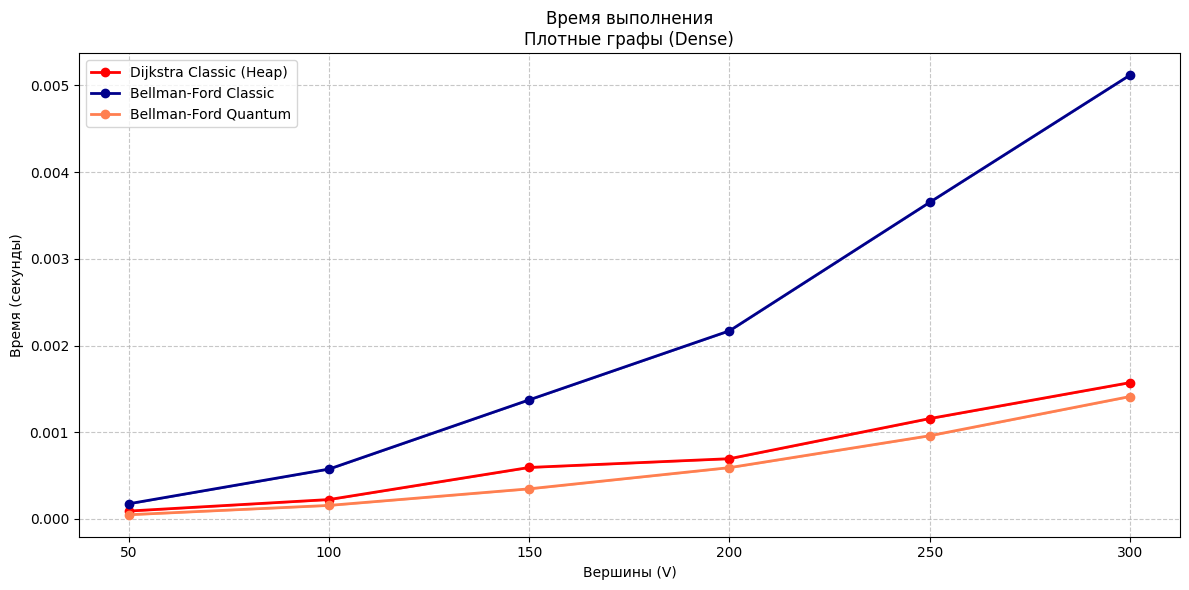

In [78]:
plot_time(filtered_res)

In [ ]:
algos1 = {
    "Dijkstra Classic (Heap)": dijkstra_classic_wrapper,
    "Dijkstra Quantum (Grover)": dijkstra_quantum_wrapper,
    "Bellman-Ford Classic": bellman_ford_classic_wrapper,
    "Bellman-Ford Quantum": bellman_ford_quantum_wrapper,
    #"Floyd-Warshall Classic": floyd_warshall_classic_wrapper,
    #"Floyd-Warshall Quantum": floyd_warshall_quantum_wrapper
}

res1 = run_experiment(algos1)